# Level 2 – Task 1: Predicting House Prices with Linear Regression

## Objective
Build and evaluate a Linear Regression model to predict house prices based on property features such as area, location, number of rooms, and other relevant attributes.

### Dataset
House Prices – Advanced Regression Techniques (Kaggle)

### Target Variable
SalePrice

In [9]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

print("All required libraries imported successfully!")

All required libraries imported successfully!


In [10]:
# Load the dataset

df = pd.read_csv("../dataset/train.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1460, 81)


In [11]:
# Display the first five rows

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [12]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [13]:
# Missing-value analysis

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values = missing_values[missing_values > 0]

print("Columns with missing values:")
display(missing_values.to_frame(name="Missing Count"))

Columns with missing values:


,Missing Count
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [14]:
# Descriptive statistics

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


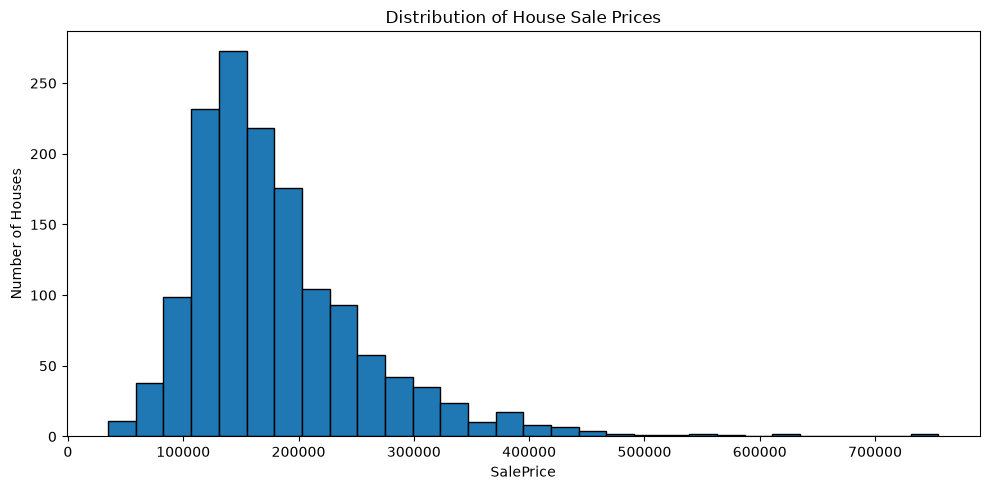

In [15]:
# Distribution of SalePrice

plt.figure(figsize=(10, 5))

plt.hist(df["SalePrice"], bins=30, edgecolor="black")

plt.title("Distribution of House Sale Prices")
plt.xlabel("SalePrice")
plt.ylabel("Number of Houses")

plt.tight_layout()
plt.show()

In [16]:
# Correlation analysis

numeric_df = df.select_dtypes(include=np.number)

correlation_with_price = (
    numeric_df.corr()["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Top 15 features correlated with SalePrice:")
display(correlation_with_price.head(15).to_frame("Correlation"))

Top 15 features correlated with SalePrice:


,Correlation
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


## Feature Selection Discussion

The correlation analysis shows that OverallQual, GrLivArea, GarageCars,
GarageArea, TotalBsmtSF, 1stFlrSF, FullBath, TotRmsAbvGrd, YearBuilt,
and YearRemodAdd have strong positive relationships with SalePrice.

OverallQual is the strongest numerical predictor, followed by GrLivArea.
These features are likely to be important because house quality, living
space, garage capacity, basement area, number of rooms, and construction
or renovation year can influence property value.

Categorical features such as Neighborhood are also expected to be useful
because location can strongly influence house prices.

The Id column will be excluded because it is only an identifier and does
not represent a meaningful house characteristic.

In [17]:
# Prepare features and target

X = df.drop(columns=["SalePrice", "Id"])
y = df["SalePrice"]

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total input features before encoding:", X.shape[1])

Numerical features: 36
Categorical features: 43
Total input features before encoding: 79


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical features: fill missing values with median
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical features: fill missing values with most frequent value
# and then apply One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing methods
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")
print("Numerical missing values → Median imputation")
print("Categorical missing values → Most-frequent imputation")
print("Categorical features → One-Hot Encoding")

Preprocessing pipeline created successfully!
Numerical missing values → Median imputation
Categorical missing values → Most-frequent imputation
Categorical features → One-Hot Encoding


In [19]:
from sklearn.model_selection import train_test_split

# Split dataset into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1168
Testing samples: 292


In [20]:
# Train Linear Regression model

from sklearn.linear_model import LinearRegression

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)

# Make predictions
y_pred = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")
print("Predictions generated successfully!")

Linear Regression model trained successfully!
Predictions generated successfully!


In [21]:
# Evaluate Linear Regression model

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 979,376,460.09
Root Mean Squared Error (RMSE): 31,294.99
R² Score: 0.8723


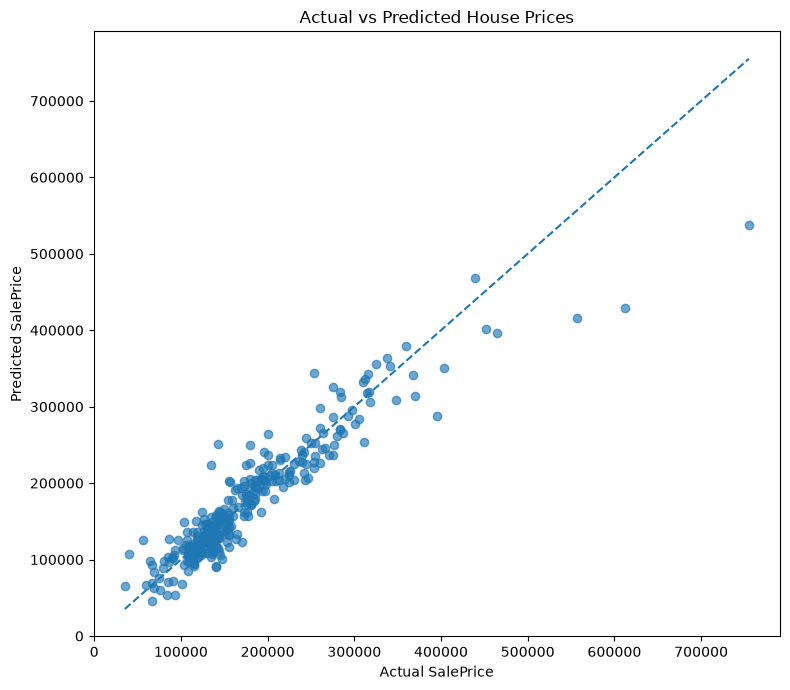

In [22]:
# Actual vs Predicted House Prices

plt.figure(figsize=(8, 7))

plt.scatter(y_test, y_pred, alpha=0.65)

# Diagonal reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")

plt.tight_layout()
plt.show()

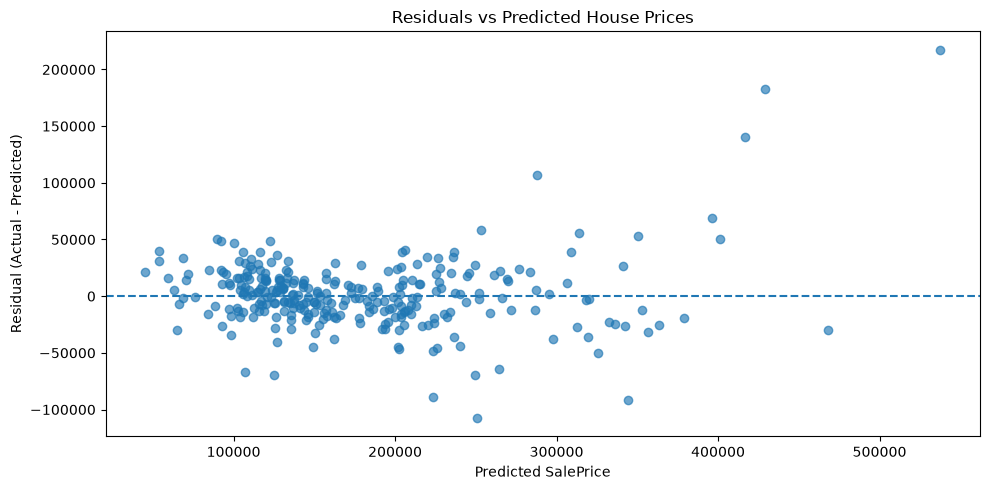

In [23]:
# Residual analysis

residuals = y_test - y_pred

plt.figure(figsize=(10, 5))

plt.scatter(y_pred, residuals, alpha=0.65)
plt.axhline(0, linestyle="--")

plt.title("Residuals vs Predicted House Prices")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

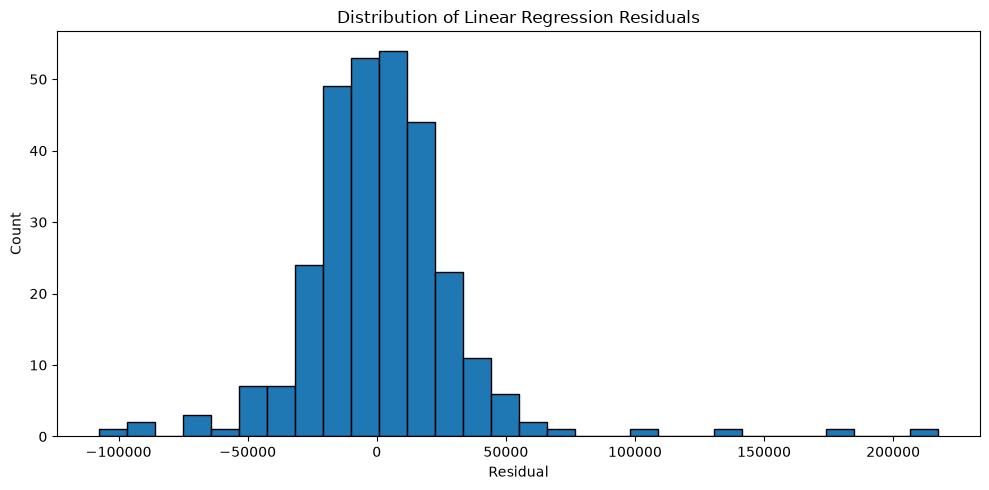

In [24]:
# Distribution of residuals

plt.figure(figsize=(10, 5))

plt.hist(residuals, bins=30, edgecolor="black")

plt.title("Distribution of Linear Regression Residuals")
plt.xlabel("Residual")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [25]:
# Feature impact analysis using Linear Regression coefficients

feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = linear_model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
})

coef_df = coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("Top 15 features by absolute coefficient:")
display(coef_df.head(15))

print("Top 10 positive-impact features:")
display(
    coef_df.sort_values("Coefficient", ascending=False)
    .head(10)[["Feature", "Coefficient"]]
)

print("Top 10 negative-impact features:")
display(
    coef_df.sort_values("Coefficient", ascending=True)
    .head(10)[["Feature", "Coefficient"]]
)

Top 15 features by absolute coefficient:


,Feature,Coefficient,Absolute_Coefficient
78,cat__Neighborhood_NoRidge,41901.268218,41901.268218
85,cat__Neighborhood_StoneBr,39134.933544,39134.933544
124,cat__RoofMatl_ClyTile,-29057.711990,29057.711990
259,cat__PoolQC_Ex,28020.792433,28020.792433
261,cat__PoolQC_Gd,-24972.333443,24972.333443
79,cat__Neighborhood_NridgHt,24777.963772,24777.963772
101,cat__Condition2_PosN,-24387.894785,24387.894785
134,cat__Exterior1st_BrkFace,23198.043843,23198.043843
153,cat__Exterior2nd_ImStucc,21429.506595,21429.506595
74,cat__Neighborhood_Mitchel,-21248.184226,21248.184226


Top 10 positive-impact features:


,Feature,Coefficient
78,cat__Neighborhood_NoRidge,41901.268218
85,cat__Neighborhood_StoneBr,39134.933544
259,cat__PoolQC_Ex,28020.792433
79,cat__Neighborhood_NridgHt,24777.963772
134,cat__Exterior1st_BrkFace,23198.043843
153,cat__Exterior2nd_ImStucc,21429.506595
180,cat__BsmtQual_Ex,20061.527068
221,cat__KitchenQual_Ex,19445.880060
50,cat__LandContour_HLS,18920.803465
69,cat__Neighborhood_Crawfor,16885.159464


Top 10 negative-impact features:


,Feature,Coefficient
124,cat__RoofMatl_ClyTile,-29057.711990
261,cat__PoolQC_Gd,-24972.333443
101,cat__Condition2_PosN,-24387.894785
74,cat__Neighborhood_Mitchel,-21248.184226
49,cat__LandContour_Bnk,-20468.188112
70,cat__Neighborhood_Edwards,-17223.304884
47,cat__LotShape_IR3,-15412.090547
71,cat__Neighborhood_Gilbert,-14890.232469
77,cat__Neighborhood_NWAmes,-14294.379434
75,cat__Neighborhood_NAmes,-13055.799494


In [26]:
# Bonus: Compare Linear Regression, Ridge and Lasso

from sklearn.linear_model import Ridge, Lasso

# Ridge Regression
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=10))
])

# Lasso Regression
lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Lasso(alpha=100, max_iter=50000))
])

# Train both models
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

# Predictions
ridge_pred = ridge_model.predict(X_test)
lasso_pred = lasso_model.predict(X_test)

# Evaluation
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

# Comparison table
model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "MSE": [mse, ridge_mse, lasso_mse],
    "RMSE": [rmse, ridge_rmse, lasso_rmse],
    "R2 Score": [r2, ridge_r2, lasso_r2]
})

display(model_results)

,Model,MSE,RMSE,R2 Score
0,Linear Regression,9.793765e+08,31294.990974,0.872316
1,Ridge,1.194765e+09,34565.369089,0.844235
2,Lasso,8.011280e+08,28304.205228,0.895555


# Final Findings and Conclusion

## Findings

- The dataset contains 1,460 house records and 81 columns.
- SalePrice was used as the target variable.
- OverallQual and GrLivArea showed the strongest numerical correlations with SalePrice.
- Missing numerical values were handled using median imputation.
- Missing categorical values were handled using most-frequent imputation.
- Categorical features were converted using One-Hot Encoding.
- The dataset was divided into 80% training data and 20% testing data.
- Linear Regression achieved an R² score of 0.8723 and an RMSE of approximately 31,294.99.
- The Actual vs Predicted plot showed that most predictions followed the general diagonal trend.
- Residual analysis showed that most errors were concentrated around zero, although larger errors were present for some higher-priced houses.
- Feature coefficient analysis identified features with positive and negative impacts on predicted prices.
- Ridge and Lasso were compared as regularized models.
- Lasso achieved the best test performance with an R² score of 0.8956 and an RMSE of approximately 28,304.21.

## Conclusion

The Linear Regression model provides a strong baseline for predicting house prices using property characteristics. The analysis demonstrated the importance of data preprocessing, categorical encoding, correlation analysis, and model evaluation. Among the three evaluated models, Lasso Regression achieved the best performance on the test dataset, indicating that regularization can improve prediction performance when many correlated and encoded features are present.